In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [7]:
df = pd.read_csv("c:\\Users\\ADMIN\\Downloads\\retail_store_inventory.csv")

# check dataset

In [9]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [11]:
df.shape

(73100, 15)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

In [15]:
df.describe()

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000


# null values

In [18]:
df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

# duplicated values

In [29]:
df.duplicated().sum()

0

# convert date column

In [31]:
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

df.drop("Date", axis=1, inplace=True)

df.head()

,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Year,Month
0,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn,2022,1
1,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn,2022,1
2,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer,2022,1
3,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn,2022,1
4,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer,2022,1


# encode categorical columns

In [35]:
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Year,Month
0,0,0,3,1,231,127,55,135.47,33.50,20,1,0,29.69,0,2022,1
1,0,1,4,2,204,150,66,144.04,63.01,20,3,0,66.16,0,2022,1
2,0,2,4,3,102,65,51,74.02,27.99,10,3,1,31.32,2,2022,1
3,0,3,4,1,469,61,164,62.18,32.72,10,0,1,34.74,0,2022,1
4,0,4,1,0,166,14,135,9.26,73.64,0,3,0,68.95,2,2022,1


# corelation heatmap

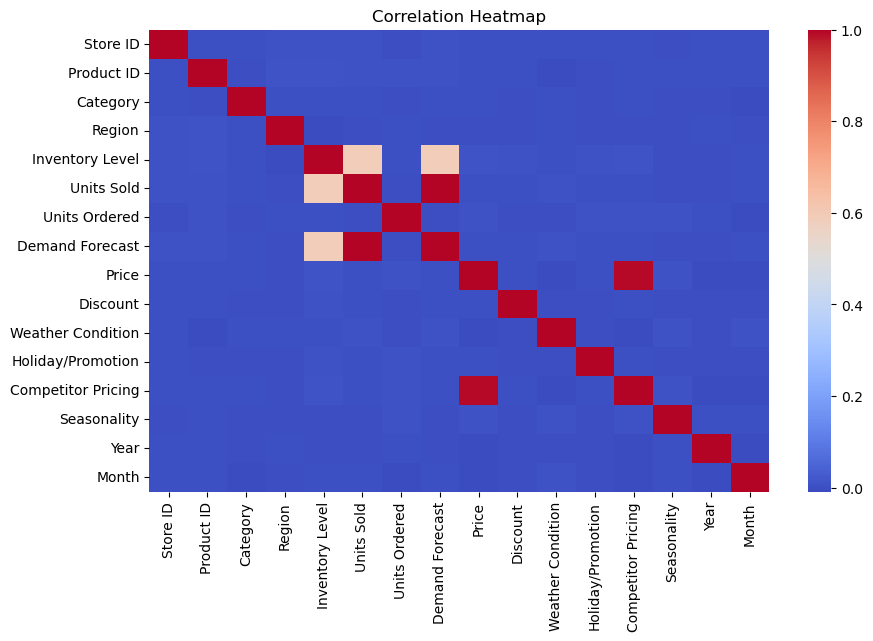

In [38]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Distribution of Target Variable

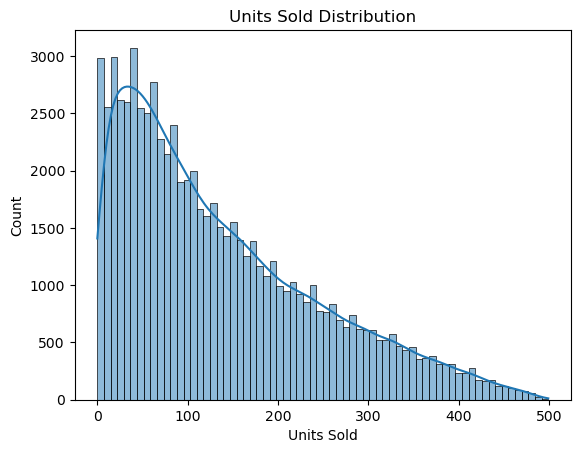

In [41]:
sns.histplot(df["Units Sold"], kde=True)
plt.title("Units Sold Distribution")
plt.show()

# features and targets

In [43]:
X = df.drop("Units Sold", axis=1)
y = df["Units Sold"]

In [66]:
print(y)

0        127
1        150
2         65
3         61
4         14
        ... 
73095      8
73096     51
73097     36
73098    264
73099      6
Name: Units Sold, Length: 73100, dtype: int64


# train test split

In [64]:
X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.2,random_state=42)
print(X_train, X_test, y_train, y_test)

       Store ID  Product ID  Category  Region  Inventory Level  Units Ordered  \
12934         1          14         0       2              316             41   
19473         3          13         0       1              349            133   
13001         0           1         3       2              394            167   
26535         1          15         0       0              345             55   
8236          1          16         3       2              209             49   
...         ...         ...       ...     ...              ...            ...   
37194         4          14         0       0              482            187   
6265          3           5         2       1              338             88   
54886         4           6         4       2              157            195   
860           3           0         0       3              391            163   
15795         4          15         2       2              136             57   

       Demand Forecast  Pri

# bulid random forest model

In [55]:
model = RandomForestRegressor(random_state=42)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

# predictions

In [60]:
y_pred = model.predict(X_test)

In [62]:
print(y_pred)

[134.47 109.51  73.56 ... 356.3  221.34 193.29]


# evaluate model

In [69]:
r2_score(y_test, y_pred)

0.99383234522931

In [71]:
mean_absolute_error(y_test, y_pred)

7.250032147742818

# actual vs predicted units sold

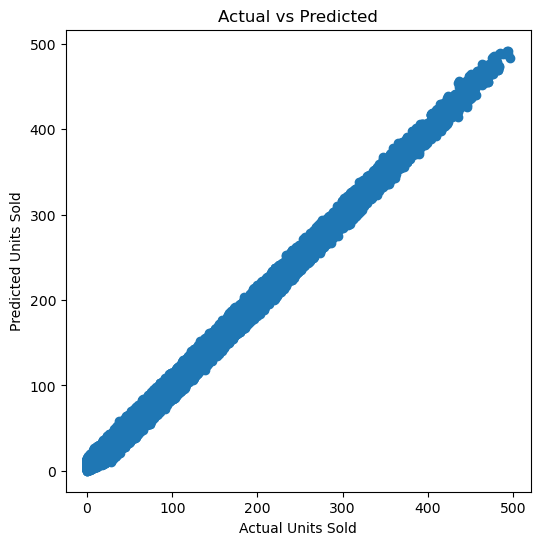

In [78]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Units Sold")
plt.ylabel("Predicted Units Sold")

plt.title("Actual vs Predicted")

plt.show()

# Distribution of Units Sold (Target Variable)
Shows how sales are distributed

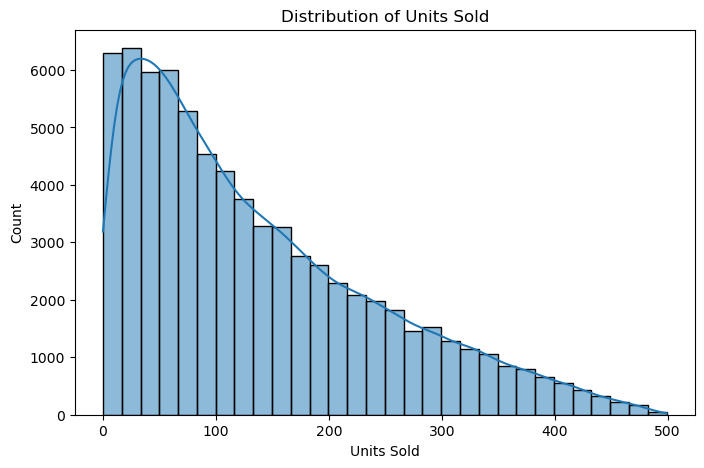

In [82]:
plt.figure(figsize=(8,5))
sns.histplot(df["Units Sold"], bins=30, kde=True)
plt.title("Distribution of Units Sold")
plt.xlabel("Units Sold")
plt.show()

# Top 10 Products by Units Sold

Identifies the best-selling products.

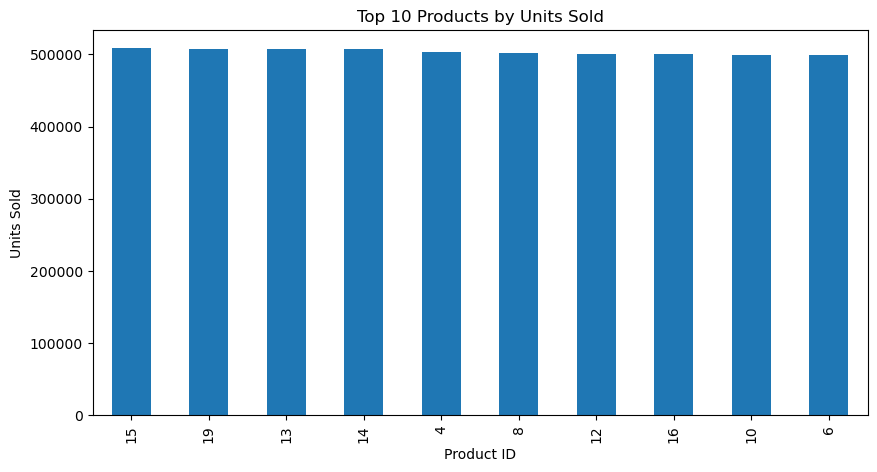

In [84]:
top_products = df.groupby("Product ID")["Units Sold"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_products.plot(kind="bar")
plt.title("Top 10 Products by Units Sold")
plt.ylabel("Units Sold")
plt.show()

# Price vs Units Sold

Examines whether product price affects sales.

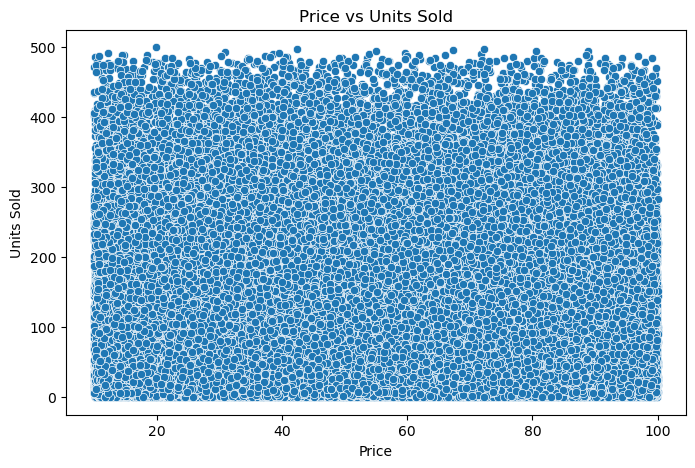

In [93]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Price", y="Units Sold", data=df)
plt.title("Price vs Units Sold")
plt.show()

# Feature Importance (After Training the Random Forest Model)

Shows which features have the greatest impact on predicting units sold.

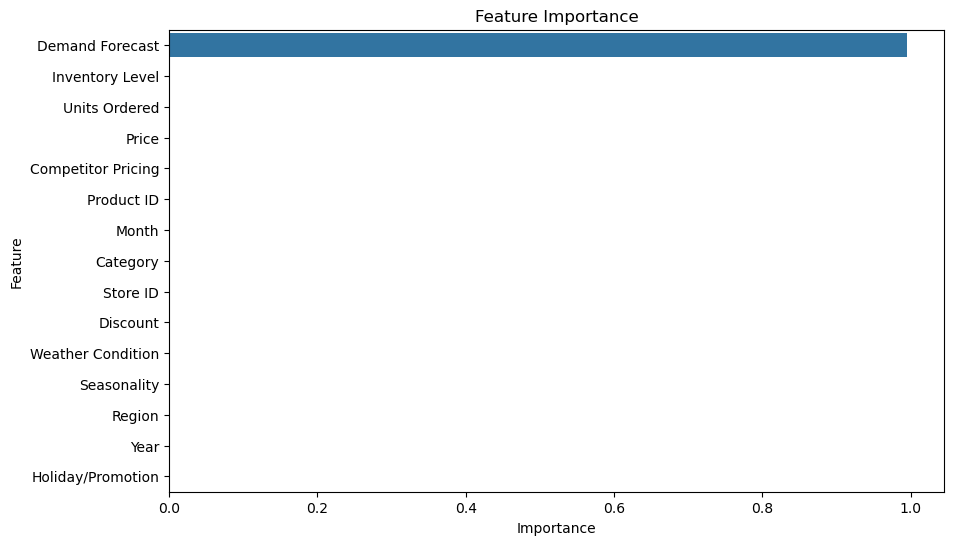

In [100]:
importance = pd.DataFrame({"Feature": X.columns,"Importance": model.feature_importances_}).sort_values(by="Importance", ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(data=importance, x="Importance", y="Feature")
plt.title("Feature Importance")
plt.show()